In [9]:
%load_ext autoreload
%autoreload 2

from karateclub import Graph2Vec
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd
import networkx as nx
import pickle
from sklearn.manifold import TSNE

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
adjs_list = pickle.load(open('adjs.pkl', 'rb'))
adjs = [np.array(adj) for adj in adjs_list]

In [11]:
df = pd.read_csv('graph_info.csv')

In [16]:

# Convert to networkx graphs
nx_graphs = [nx.from_numpy_array(A) for A in adjs]

model = Graph2Vec(dimensions=16, wl_iterations=3, epochs=20)
model.fit(nx_graphs)
embeddings = model.get_embedding()

# Then use UMAP/t-SNE
embedding_2d = TSNE(n_components=2).fit_transform(embeddings)


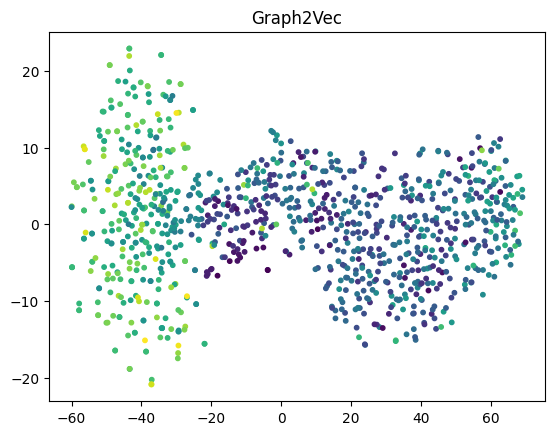

In [21]:
plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], s=10, c=df['edge_prob'], cmap='viridis')
plt.title("Graph2Vec")
plt.show()